<a href="https://colab.research.google.com/github/RizkyFirdiansyah/PCVK_Ganjil2026/blob/main/Week04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<BarContainer object of 256 artists>

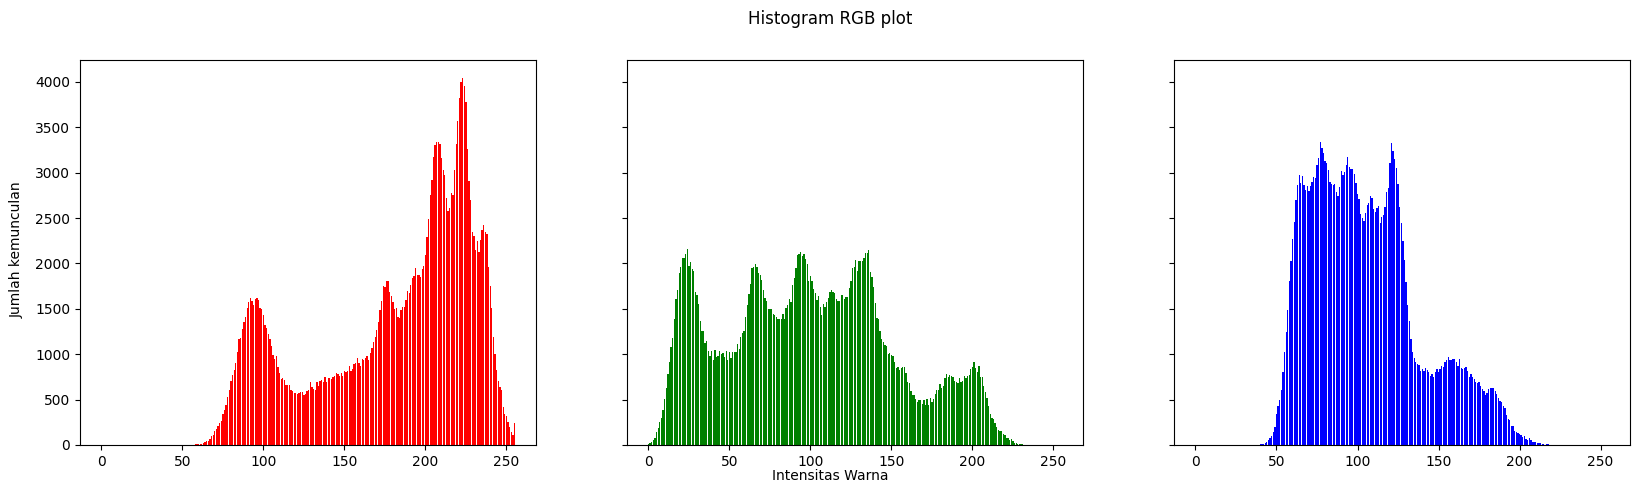

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK2026/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

In [ ]:
# Perbandingan histogram

def verify_histogram_methods(image_path):
    img = cv.imread(image_path)

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w, c = img_rgb.shape

    # Metode Manual
    hist_manual = np.zeros((3, 256), dtype=np.int64)
    for y in range(h):
        for x in range(w):
            hist_manual[0, img_rgb[y, x, 0]] += 1
            hist_manual[1, img_rgb[y, x, 1]] += 1
            hist_manual[2, img_rgb[y, x, 2]] += 1

    # Metode numpy.histogram
    hist_numpy = np.zeros((3, 256), dtype=np.int64)
    for ch in range(3):
        counts, _ = np.histogram(img_rgb[:, :, ch], bins=256, range=(0, 256))
        hist_numpy[ch] = counts

    # Metode cv.calcHist
    hist_cv = np.zeros((3, 256), dtype=np.int64)
    for ch in range(3):
        # cv.calcHist menerima list image, channel 0, mask None, histSize 256, range [0, 256]
        h_cv = cv.calcHist([img_rgb], [ch], None, [256], [0, 256])
        hist_cv[ch] = h_cv.flatten().astype(np.int64)

    # Menghitung Selisih Maksimum
    diff_manual_np = np.max(np.abs(hist_manual - hist_numpy))
    diff_manual_cv = np.max(np.abs(hist_manual - hist_cv))
    diff_np_cv = np.max(np.abs(hist_numpy - hist_cv))

    print(f"=== HASIL PEMBUKTIAN SELISIH HINGGA NIKAL BINS ({image_path}) ===")
    print(f"Selisih Maksimum (Manual vs NumPy) : {diff_manual_np}")
    print(f"Selisih Maksimum (Manual vs OpenCV): {diff_manual_cv}")
    print(f"Selisih Maksimum (NumPy vs OpenCV) : {diff_np_cv}")

    if diff_manual_np == 0 and diff_manual_cv == 0 and diff_np_cv == 0:
        print("Kesimpulan: Selisih bernilai NOL, ketiga metode menghasilkan histogram yang persis sama.\n")
    else:
        print("Kesimpulan: Selisih tidak NOL, ada metode yang menghasilkan histogram yang berbeda.\n")

# Pembuktian pada Lenna.png
verify_histogram_methods('/content/drive/MyDrive/PCVK2026/Lenna.png')

#  Pembuktian pada KTP.jpg
verify_histogram_methods('/content/drive/MyDrive/PCVK2026/ktpBlur.jpg')

=== HASIL PEMBUKTIAN SELISIH HINGGA NIKAL BINS (/content/drive/MyDrive/PCVK2026/Lenna.png) ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0
Selisih Maksimum (NumPy vs OpenCV) : 0
Kesimpulan: Selisih bernilai NOL, ketiga metode menghasilkan histogram yang persis sama.

=== HASIL PEMBUKTIAN SELISIH HINGGA NIKAL BINS (/content/drive/MyDrive/PCVK2026/ktpBlur.jpg) ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0
Selisih Maksimum (NumPy vs OpenCV) : 0
Kesimpulan: Selisih bernilai NOL, ketiga metode menghasilkan histogram yang persis sama.



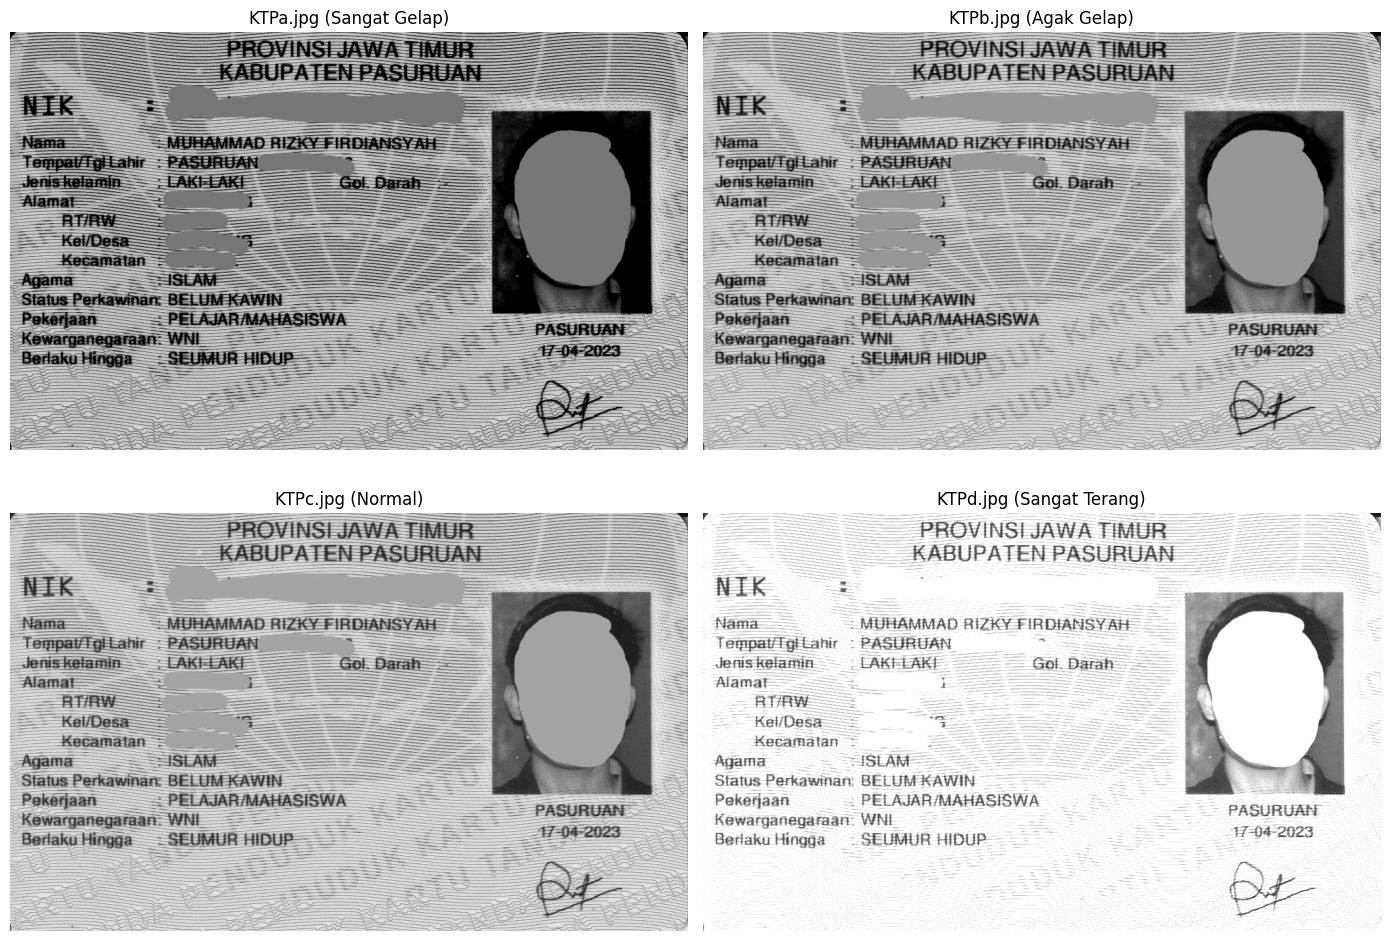

In [25]:
path_ktp = '/content/drive/MyDrive/PCVK2026/ktpBlur.jpg'
img_base = cv.imread(path_ktp, cv.IMREAD_GRAYSCALE)

# Simulasi 4 variasi pencahayaan (ktp1a s/d ktp1d)

# 1. Sangat Gelap (Gamma 0.3 / Brightness -80)
ktp_1a = np.clip(img_base.astype(np.int16) - 90, 0, 255).astype(np.uint8)

# 2. Agak Gelap (Brightness -40)
ktp_1b = np.clip(img_base.astype(np.int16) - 40, 0, 255).astype(np.uint8)

# 3. Normal / Terang Seimbang (Kondisi Asli)
ktp_1c = img_base.copy()

# 4. Sangat Terang / Silau (Brightness +90)
ktp_1d = np.clip(img_base.astype(np.int16) + 90, 0, 255).astype(np.uint8)

dict_ktp = {
    'KTPa.jpg (Sangat Gelap)': ktp_1a,
    'KTPb.jpg (Agak Gelap)': ktp_1b,
    'KTPc.jpg (Normal)': ktp_1c,
    'KTPd.jpg (Sangat Terang)': ktp_1d
}

# Plotting 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (nama, img_data) in enumerate(dict_ktp.items()):
    axes[i].imshow(img_data, cmap='gray')
    axes[i].set_title(nama)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


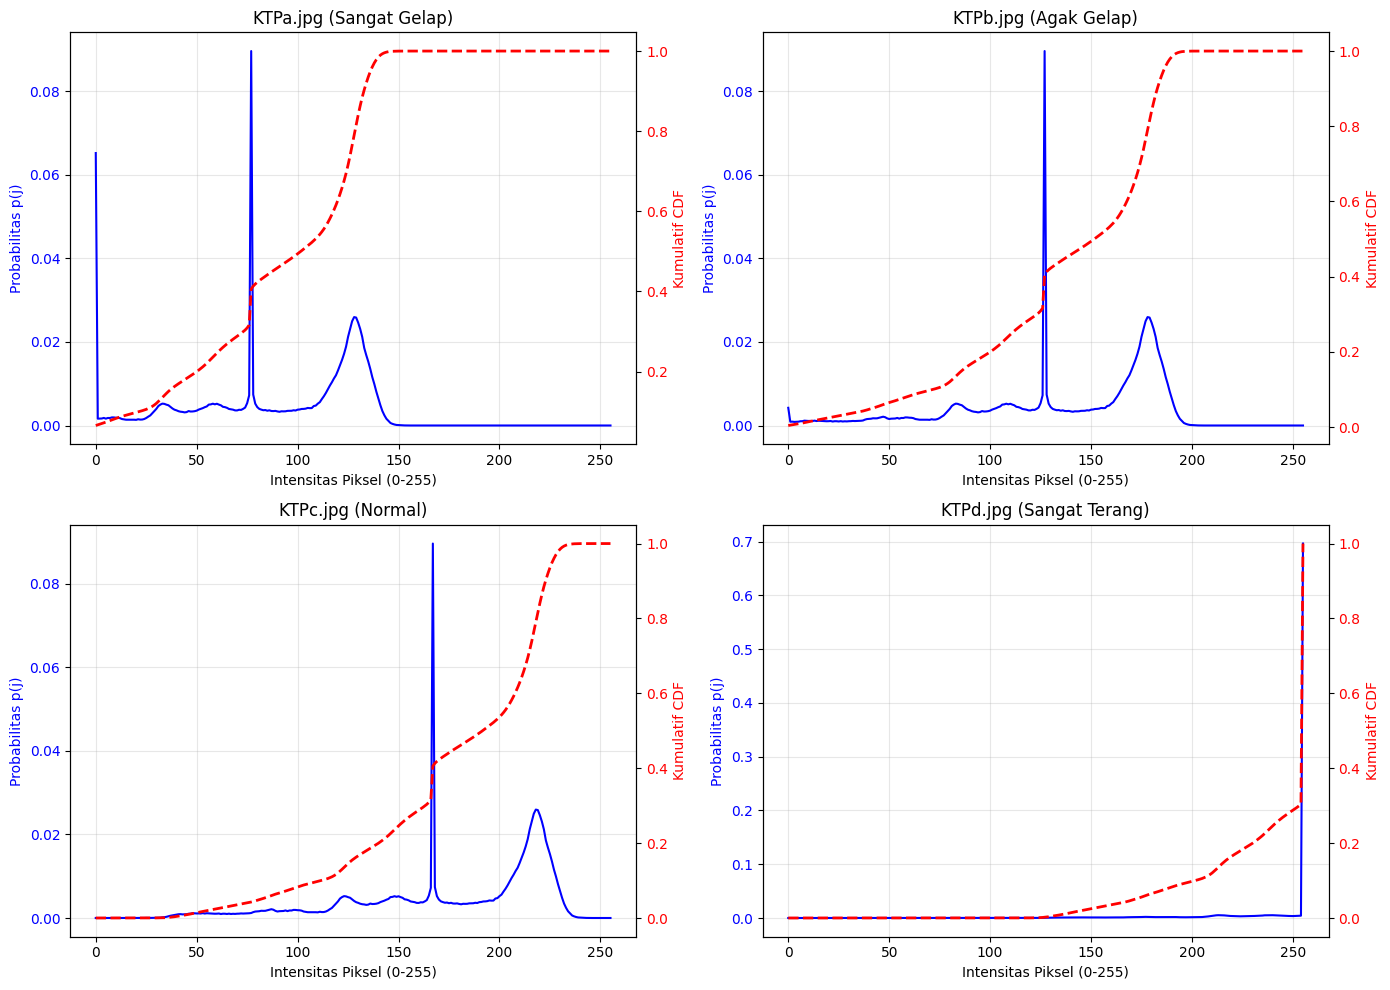

In [26]:
# Histogram Ternormalisasi dan Perbedaan Kurva CDF

# Plotting 2x2
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
axes2 = axes2.ravel()

for idx, (title, img) in enumerate(dict_ktp.items()):
    # Hitung Histogram Raw
    hist, _ = np.histogram(img.flatten(), 256, [0, 256])

    # Histogram Ternormalisasi p(j)
    p_j = hist / float(img.size)

    # Cumulative Distribution Function (CDF)
    cdf = p_j.cumsum()

    # Sumbu Y Sekunder untuk CDF
    ax1 = axes2[idx]
    ax2 = ax1.twinx()

    # Plot p(j)
    ax1.plot(p_j, color='blue', label='p(j) Normalized Hist')
    ax1.set_xlabel('Intensitas Piksel (0-255)')
    ax1.set_ylabel('Probabilitas p(j)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Plot CDF
    ax2.plot(cdf, color='red', linestyle='--', linewidth=2, label='CDF')
    ax2.set_ylabel('Kumulatif CDF', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()